Mounted at /content/drive
✅ Libraries installed
✅ Libraries loaded
   Device : cuda
   GPU    : Tesla T4
   VRAM   : 15.6 GB
✅ Features dir : /content/drive/MyDrive/Colab Notebooks/AIP_V2/features
✅ Figures dir  : /content/drive/MyDrive/Colab Notebooks/AIP_V2/figures
✅ Model        : dmis-lab/biobert-base-cased-v1.2
✅ Batch size   : 32
✅ Pooling      : mean
✅ Max length   : 64
✅ Embedding dim: 768 (base) or 1024 (large)
✅ Parsed 2435 sequences
   Positive (AIP)    : 974
   Negative (non-AIP): 1461
   Length range      : 11 – 46 aa
Loading BioBERT tokenizer and model: dmis-lab/biobert-base-cased-v1.2
(First run downloads ~400 MB — cached afterwards)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ BioBERT model loaded
   Hidden size    : 768
   Num layers     : 12
   Attention heads: 12
   Vocab size     : 28996
Original  ( 12 aa) : PRIVLDVASSVF
Processed ( 23 ch) : P R I V L D V A S S V F...

Token count for sample: 14 (includes [CLS] and [SEP])
Expected ≈ 14 (seq len + 2 special tokens)
Extracting BioBERT embeddings...
  Sequences     : 2435
  Batch size    : 32
  Total batches : 77
  Pooling       : mean
  Device        : cuda

  [  5/77] 160/2435 sequences done
  [ 10/77] 320/2435 sequences done
  [ 15/77] 480/2435 sequences done
  [ 20/77] 640/2435 sequences done
  [ 25/77] 800/2435 sequences done
  [ 30/77] 960/2435 sequences done
  [ 35/77] 1120/2435 sequences done
  [ 40/77] 1280/2435 sequences done
  [ 45/77] 1440/2435 sequences done
  [ 50/77] 1600/2435 sequences done
  [ 55/77] 1760/2435 sequences done
  [ 60/77] 1920/2435 sequences done
  [ 65/77] 2080/2435 sequences done
  [ 70/77] 2240/2435 sequences done
  [ 75/77] 2400/2435 sequences done
  [ 77/77] 2435/2435 s

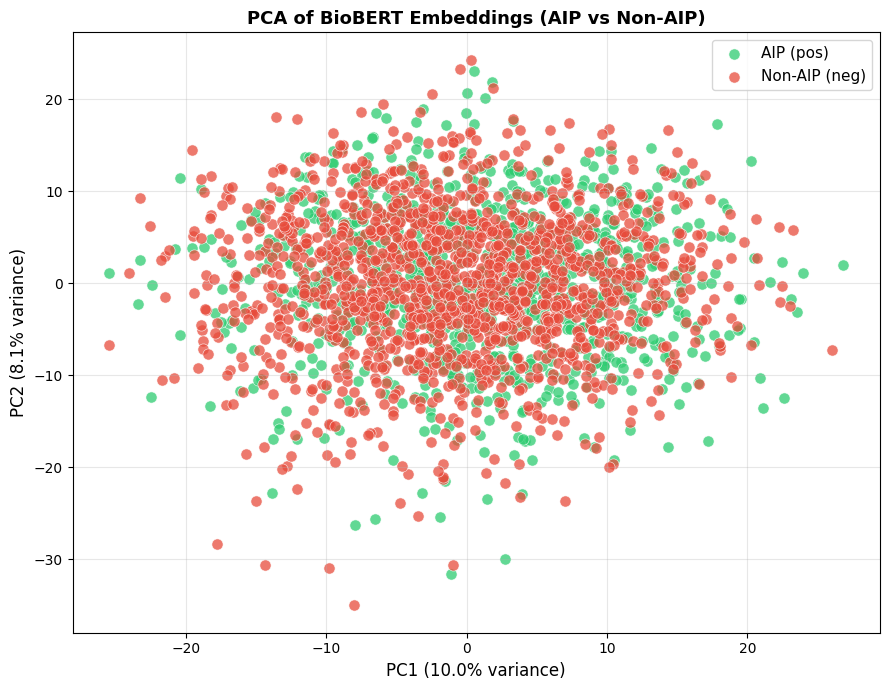

✅ PCA plot saved
Running t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


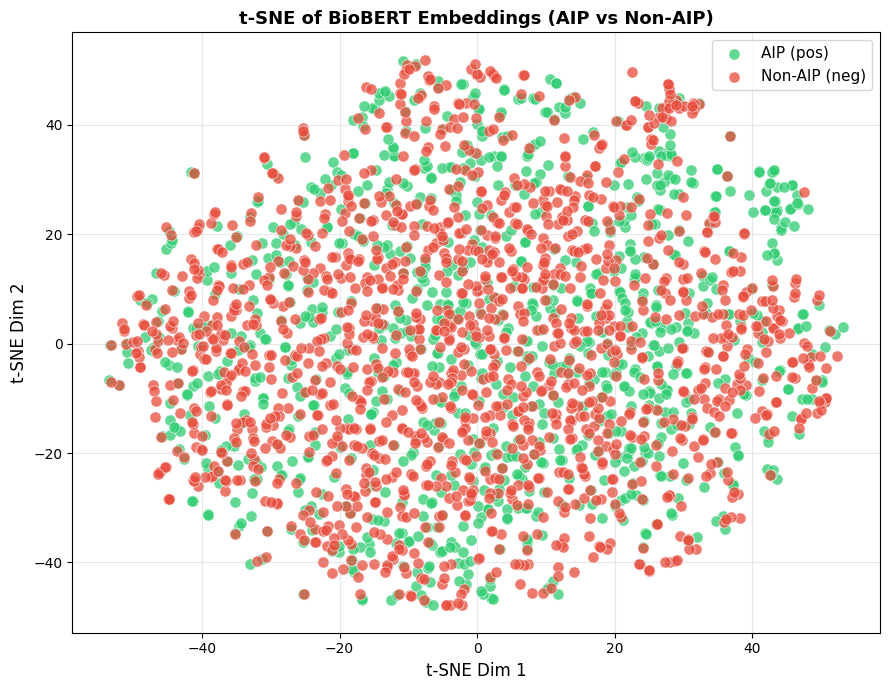

✅ t-SNE plot saved
Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


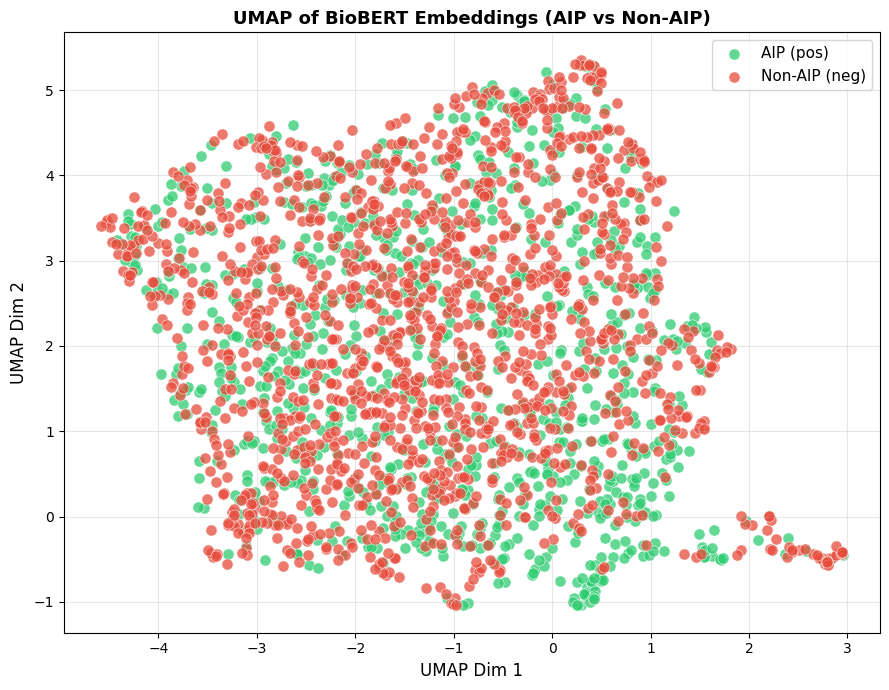

✅ UMAP plot saved


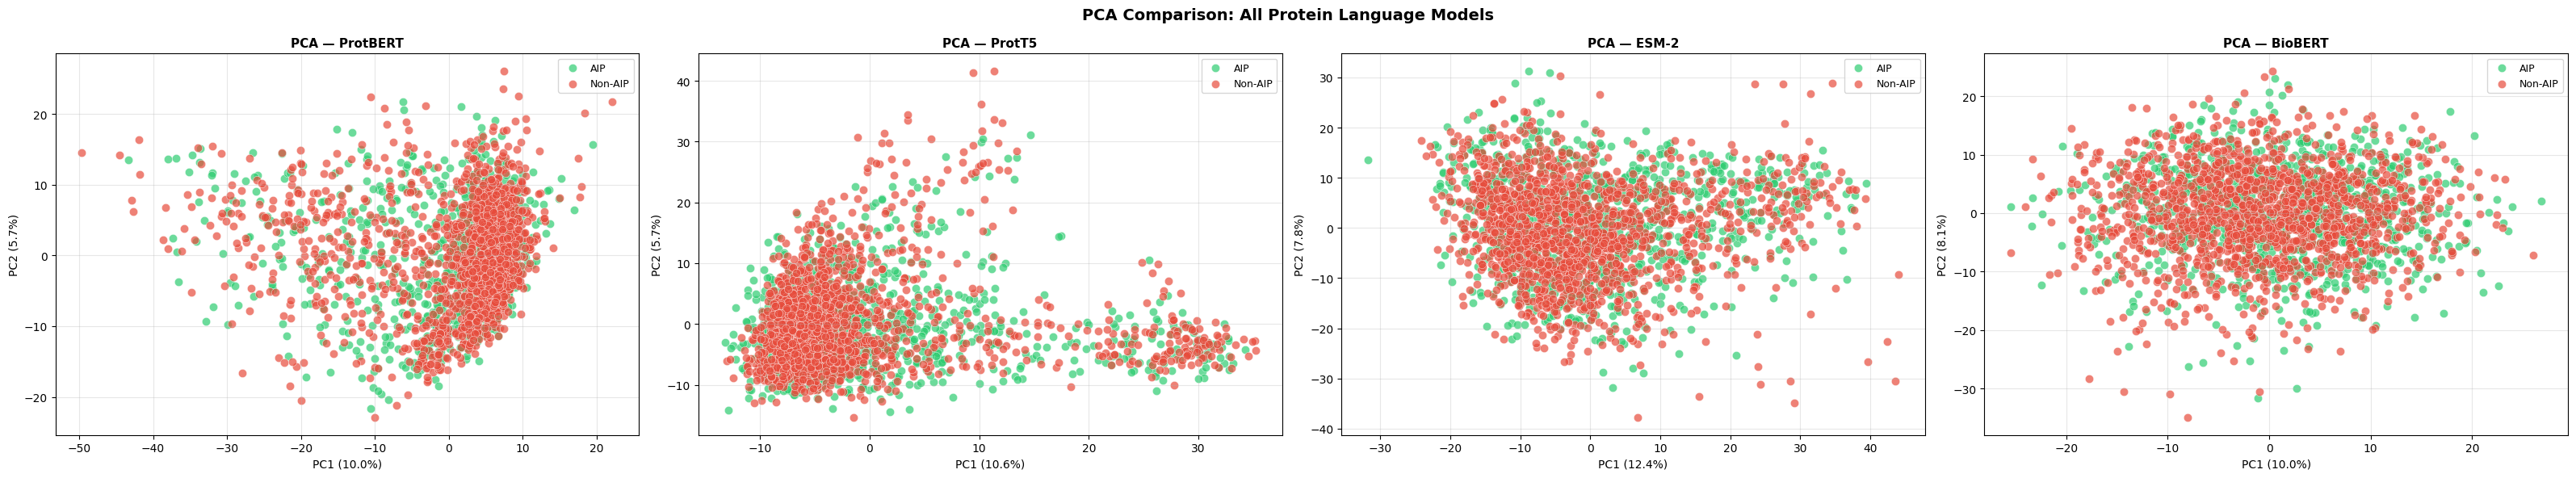

✅ All-PLM comparison plot saved (4 models shown)


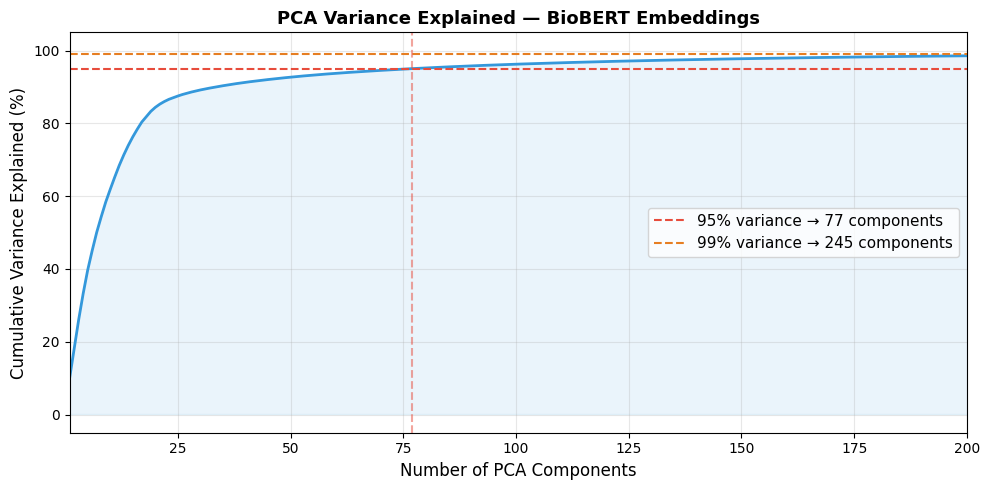

✅ Variance plot saved
   77 components → 95% variance (vs full 768 dims)
   245 components → 99% variance
✅ PCA-reduced features saved
   File  : /content/drive/MyDrive/Colab Notebooks/AIP_V2/features/BioBERT_PCA_features.csv
   Shape : (2435, 80)  (77 dims vs original 768)
✅ BioBERT Feature Extraction COMPLETE
   Full CSV   : /content/drive/MyDrive/Colab Notebooks/AIP_V2/features/BioBERT_features.csv
   Shape      : (2435, 770)
   Raw .npy   : /content/drive/MyDrive/Colab Notebooks/AIP_V2/features/BioBERT_embeddings.npy
   PCA CSV    : /content/drive/MyDrive/Colab Notebooks/AIP_V2/features/BioBERT_PCA_features.csv
   PCA Shape  : (2435, 80)
   Figures    : /content/drive/MyDrive/Colab Notebooks/AIP_V2/figures
   Model      : dmis-lab/biobert-base-cased-v1.2
   Pooling    : mean


In [ ]:
# ============================================================
#   CELL 1 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


# ============================================================
#   CELL 2 — Install Required Libraries
# ============================================================
!pip install transformers torch sentencepiece umap-learn -q

print("✅ Libraries installed")


# ============================================================
#   CELL 3 — Import Libraries
# ============================================================
import os
import gc
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import umap
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import DataLoader, Dataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# Check GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Libraries loaded")
print(f"   Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("   ⚠️  No GPU — running on CPU (slower)")


# ============================================================
#   CELL 4 — Configuration (Edit paths here)
# ============================================================

# FOR DRIVE FILE LOCATION
FASTA_PATH  = "/content/drive/MyDrive/Colab Notebooks/AIP_V2/data/AIP.fasta"
OUTPUT_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP_V2/features"
FIGURES_DIR = "/content/drive/MyDrive/Colab Notebooks/AIP_V2/figures"

# FOR LOCAL
# FASTA_PATH  = "../../data/raw/AIP_ind.fasta"
# OUTPUT_DIR  = "../../results/figures"

OUTPUT_CSV  = os.path.join(OUTPUT_DIR, "BioBERT_features.csv")
OUTPUT_NPY  = os.path.join(OUTPUT_DIR, "BioBERT_embeddings.npy")

# ── BioBERT Model Variants ───────────────────────────────────
#
#  Model                                    Embed-dim  Notes
#  dmis-lab/biobert-base-cased-v1.2         768        ✅ recommended
#  dmis-lab/biobert-large-cased-v1.1        1024       larger, slower
#  dmis-lab/biobert-base-cased-v1.1         768        older version
#  dmis-lab/biobert-v1.1                    768        original paper
#
#  ✅ BioBERT is pre-trained on PubMed abstracts + PMC full-text
#     It understands biomedical terminology including peptide/protein
#     context from biomedical literature.
#
#  ⚠️  Note: BioBERT works on word-level biomedical text.
#     For protein sequences we feed space-separated amino acids
#     (same format as ProtBERT) since BioBERT uses WordPiece
#     tokenization and single amino acid letters map to tokens.
#
# ────────────────────────────────────────────────────────────
MODEL_NAME  = "dmis-lab/biobert-base-cased-v1.2"

# Batch size — reduce if OOM error
# T4 GPU (16 GB): 32 is safe for base model
# CPU only      : 8
BATCH_SIZE  = 32

# Pooling strategy
#   "mean" — average over all non-padding tokens (recommended ✅)
#   "cls"  — use [CLS] token at position 0
#   "max"  — max pooling over all tokens
POOLING     = "mean"

# Max sequence length for tokenizer
# BioBERT supports up to 512 tokens
# For short peptides (avg 16 aa) 64 is enough and faster
MAX_LENGTH  = 64

os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"✅ Features dir : {OUTPUT_DIR}")
print(f"✅ Figures dir  : {FIGURES_DIR}")
print(f"✅ Model        : {MODEL_NAME}")
print(f"✅ Batch size   : {BATCH_SIZE}")
print(f"✅ Pooling      : {POOLING}")
print(f"✅ Max length   : {MAX_LENGTH}")
print(f"✅ Embedding dim: 768 (base) or 1024 (large)")


# ============================================================
#   CELL 5 — FASTA Parser
# ============================================================

def parse_fasta(filepath):
    """Parse FASTA file → DataFrame with seq_id, sequence, label"""
    entries    = []
    current_id = None

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                current_id = line[1:]
            elif line and current_id:
                label = 1 if current_id.startswith("pos") else 0
                entries.append({
                    "seq_id"  : current_id,
                    "sequence": line.upper(),
                    "label"   : label
                })

    df = pd.DataFrame(entries)
    print(f"✅ Parsed {len(df)} sequences")
    print(f"   Positive (AIP)    : {df['label'].sum()}")
    print(f"   Negative (non-AIP): {(df['label']==0).sum()}")
    print(f"   Length range      : {df['sequence'].apply(len).min()} – "
          f"{df['sequence'].apply(len).max()} aa")
    return df

df_seq = parse_fasta(FASTA_PATH)
df_seq.head(3)


# ============================================================
#   CELL 6 — Load BioBERT Model & Tokenizer
# ============================================================
#
#  BioBERT vs ProtBERT vs ESM-2 key differences:
#
#  ProtBERT  → trained on protein sequences only
#  ESM-2     → trained on protein sequences only
#  BioBERT   → trained on biomedical TEXT (PubMed + PMC)
#               captures biomedical literature context
#
#  Why use BioBERT for peptides?
#  ✅ Understands biomedical context (inflammation, peptide, etc.)
#  ✅ Good when combining sequence + literature-based features
#  ✅ 768-dim embeddings, same as ProtBERT base
#
#  ⚠️  BioBERT uses WordPiece tokenizer — same as original BERT
#      Single amino acid letters become individual tokens
#      Space-separated format ensures correct tokenization
#
# ============================================================

print(f"Loading BioBERT tokenizer and model: {MODEL_NAME}")
print("(First run downloads ~400 MB — cached afterwards)\n")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    do_lower_case = False    # BioBERT is case-sensitive
)

model = AutoModel.from_pretrained(MODEL_NAME)
model = model.to(DEVICE)
model.eval()

print(f"✅ BioBERT model loaded")
print(f"   Hidden size    : {model.config.hidden_size}")
print(f"   Num layers     : {model.config.num_hidden_layers}")
print(f"   Attention heads: {model.config.num_attention_heads}")
print(f"   Vocab size     : {model.config.vocab_size}")


# ============================================================
#   CELL 7 — Sequence Preprocessing for BioBERT
# ============================================================
#
#  BioBERT uses WordPiece tokenizer — designed for text.
#  To ensure each amino acid maps to exactly one token,
#  we space-separate the sequence just like ProtBERT.
#
#  "ACDE"  →  "A C D E"
#
#  Non-standard amino acids are replaced with X (unknown).
#
# ============================================================

def preprocess_sequence(sequence):
    """
    Format protein sequence for BioBERT tokenizer:
    1. Uppercase
    2. Replace non-standard AAs (U, Z, O, B) with X
    3. Space-separate every amino acid
       "ACDE" → "A C D E"
    """
    sequence = sequence.upper()
    sequence = re.sub(r"[UZOB]", "X", sequence)
    return " ".join(list(sequence))


# Preview
sample    = df_seq["sequence"].iloc[0]
processed = preprocess_sequence(sample)
print(f"Original  ({len(sample):>3d} aa) : {sample}")
print(f"Processed ({len(processed):>3d} ch) : {processed[:60]}...")

# Verify tokenization works correctly
test_tokens = tokenizer(processed, return_tensors="pt")
print(f"\nToken count for sample: {test_tokens['input_ids'].shape[1]} "
      f"(includes [CLS] and [SEP])")
print(f"Expected ≈ {len(sample) + 2} (seq len + 2 special tokens)")


# ============================================================
#   CELL 8 — PyTorch Dataset
# ============================================================

class PeptideDataset(Dataset):
    """Dataset for batched BioBERT inference."""

    def __init__(self, sequences, tokenizer,
                 max_length=MAX_LENGTH):
        self.sequences  = [preprocess_sequence(s) for s in sequences]
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.sequences[idx],
            return_tensors     = "pt",
            padding            = "max_length",
            truncation         = True,
            max_length         = self.max_length,
            add_special_tokens = True    # adds [CLS] and [SEP]
        )
        return {
            "input_ids"     : encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "token_type_ids": encoded["token_type_ids"].squeeze(0),
        }


# ============================================================
#   CELL 9 — BioBERT Embedding Extraction
# ============================================================

def pool_embeddings(hidden_states, attention_mask, strategy="mean"):
    """
    Pool token-level embeddings → one fixed-size vector per sequence.

    BioBERT token layout (same as original BERT):
      position 0      = [CLS] token
      position 1..L   = amino acid tokens
      position L+1    = [SEP] token
      position L+2..  = [PAD] tokens

    attention_mask: 1 = real token, 0 = padding

    For mean pooling we use ALL non-padding tokens including
    [CLS] and [SEP] — this is standard BioBERT usage.
    To exclude special tokens, slice [1:-1] per sequence.
    """
    if strategy == "cls":
        # [CLS] token at position 0 — standard BERT classification
        return hidden_states[:, 0, :]

    elif strategy == "mean":
        # Average over all non-padding tokens
        mask           = attention_mask.unsqueeze(-1).float()
        sum_emb        = (hidden_states * mask).sum(dim=1)
        count          = mask.sum(dim=1).clamp(min=1e-9)
        return sum_emb / count

    elif strategy == "max":
        # Element-wise max over non-padding tokens
        mask           = attention_mask.unsqueeze(-1).float()
        hidden_states  = hidden_states.masked_fill(mask == 0, -1e9)
        return hidden_states.max(dim=1).values

    else:
        raise ValueError(f"Unknown pooling: '{strategy}'. "
                         f"Choose 'mean', 'cls', or 'max'.")


def extract_biobert_embeddings(df, tokenizer, model, device,
                                batch_size=BATCH_SIZE,
                                pooling=POOLING):
    """
    Extract BioBERT embeddings for all sequences in batches.

    Returns:
        embeddings : np.ndarray shape (N, hidden_size)
                     e.g. (245, 768) for biobert-base
    """
    sequences      = df["sequence"].tolist()
    dataset        = PeptideDataset(sequences, tokenizer)
    loader         = DataLoader(dataset, batch_size=batch_size,
                                shuffle=False, num_workers=0)
    all_embeddings = []
    total_batches  = len(loader)

    print(f"Extracting BioBERT embeddings...")
    print(f"  Sequences     : {len(sequences)}")
    print(f"  Batch size    : {batch_size}")
    print(f"  Total batches : {total_batches}")
    print(f"  Pooling       : {pooling}")
    print(f"  Device        : {device}\n")

    with torch.no_grad():
        for batch_idx, batch in enumerate(loader):

            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            token_type_ids = batch["token_type_ids"].to(device)

            # BioBERT forward pass
            # outputs.last_hidden_state: (batch, seq_len, hidden_size)
            outputs = model(
                input_ids      = input_ids,
                attention_mask = attention_mask,
                token_type_ids = token_type_ids
            )

            hidden_states = outputs.last_hidden_state

            # Pool → (batch, hidden_size)
            pooled = pool_embeddings(
                hidden_states, attention_mask, strategy=pooling
            )

            all_embeddings.append(pooled.cpu().numpy())

            # Progress
            if (batch_idx + 1) % 5 == 0 or \
               (batch_idx + 1) == total_batches:
                done = min((batch_idx + 1) * batch_size,
                           len(sequences))
                print(f"  [{batch_idx+1:>3}/{total_batches}] "
                      f"{done}/{len(sequences)} sequences done")

            # Free GPU cache periodically
            if device.type == "cuda" and \
               (batch_idx + 1) % 10 == 0:
                torch.cuda.empty_cache()
                gc.collect()

    embeddings = np.vstack(all_embeddings)
    print(f"\n✅ Extraction complete — shape: {embeddings.shape}")
    return embeddings


embeddings = extract_biobert_embeddings(
    df_seq, tokenizer, model, DEVICE
)


# ============================================================
#   CELL 10 — Build Feature DataFrame
# ============================================================

embedding_dim = embeddings.shape[1]
col_names     = [f"BioBERT_{i}" for i in range(embedding_dim)]

df_emb    = pd.DataFrame(embeddings, columns=col_names)
df_biobert = pd.concat([
    df_seq[["seq_id", "sequence", "label"]].reset_index(drop=True),
    df_emb
], axis=1)
# ── REMOVED ──────────────────────────────────────────────
# df_biobert.insert(2, "length", df_biobert["sequence"].apply(len))
# ─────────────────────────────────────────────────────────────────

# ── CHANGED (Block): drop sequence & length, move label to end ──
df_biobert = df_biobert.drop(columns=["sequence"])                        # ← remove sequence column
cols   = [c for c in df_biobert.columns if c != "label"] + ["label"] # ← move label to end
df_biobert = df_biobert[cols]                                             # ← reorder columns
# ────────────────────────────────────────────────────────────────

emb_cols = [c for c in df_biobert.columns if c.startswith("BioBERT_")]

print(f"✅ Feature DataFrame built")
print(f"   Shape   : {df_biobert.shape}")
print(f"      Columns : seq_id, BioBERT_0...BioBERT_767 (768 features), label")  # ← CHANGED: updated column description
df_biobert.iloc[:3, :8]


# ============================================================
#   CELL 11 — Validate Output
# ============================================================

print("── Validation ──────────────────────────────────────")
print(f"Embedding dimension  : {len(emb_cols)}")
print(f"Missing values       : "
      f"{df_biobert[emb_cols].isnull().sum().sum()}")
print(f"Value range          : "
      f"{df_biobert[emb_cols].values.min():.4f} – "
      f"{df_biobert[emb_cols].values.max():.4f}")
print(f"Mean (pos class)     : "
      f"{df_biobert[df_biobert['label']==1][emb_cols].values.mean():.6f}")
print(f"Mean (neg class)     : "
      f"{df_biobert[df_biobert['label']==0][emb_cols].values.mean():.6f}")
print(f"Std  (pos class)     : "
      f"{df_biobert[df_biobert['label']==1][emb_cols].values.std():.6f}")
print(f"Std  (neg class)     : "
      f"{df_biobert[df_biobert['label']==0][emb_cols].values.std():.6f}")
print("✅ Validation complete")


# ============================================================
#   CELL 12 — Scale Embeddings for Visualization
# ============================================================

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_biobert[emb_cols].values)
print(f"✅ Scaled — shape: {X_scaled.shape}  mean≈0  std≈1")


# ============================================================
#   CELL 13 — Visualization 1: PCA 2D Plot
# ============================================================

pca_2d  = PCA(n_components=2, random_state=42)
X_pca   = pca_2d.fit_transform(X_scaled)
var_exp = pca_2d.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(9, 7))

for label, color, name in [(1, "#2ecc71", "AIP (pos)"),
                            (0, "#e74c3c", "Non-AIP (neg)")]:
    mask = df_biobert["label"] == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=name, alpha=0.75,
               s=65, edgecolors="white", linewidths=0.5)

ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}% variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}% variance)", fontsize=12)
ax.set_title("PCA of BioBERT Embeddings (AIP vs Non-AIP)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "BioBERT_PCA.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ PCA plot saved")


# ============================================================
#   CELL 14 — Visualization 2: t-SNE 2D Plot
# ============================================================

print("Running t-SNE...")
tsne   = TSNE(n_components=2, random_state=42,
              perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))

for label, color, name in [(1, "#2ecc71", "AIP (pos)"),
                            (0, "#e74c3c", "Non-AIP (neg)")]:
    mask = df_biobert["label"] == label
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=color, label=name, alpha=0.75,
               s=65, edgecolors="white", linewidths=0.5)

ax.set_xlabel("t-SNE Dim 1", fontsize=12)
ax.set_ylabel("t-SNE Dim 2", fontsize=12)
ax.set_title("t-SNE of BioBERT Embeddings (AIP vs Non-AIP)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "BioBERT_tSNE.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ t-SNE plot saved")


# ============================================================
#   CELL 15 — Visualization 3: UMAP 2D Plot
# ============================================================

print("Running UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42,
                    n_neighbors=15, min_dist=0.1)
X_umap  = reducer.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))

for label, color, name in [(1, "#2ecc71", "AIP (pos)"),
                            (0, "#e74c3c", "Non-AIP (neg)")]:
    mask = df_biobert["label"] == label
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
               c=color, label=name, alpha=0.75,
               s=65, edgecolors="white", linewidths=0.5)

ax.set_xlabel("UMAP Dim 1", fontsize=12)
ax.set_ylabel("UMAP Dim 2", fontsize=12)
ax.set_title("UMAP of BioBERT Embeddings (AIP vs Non-AIP)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "BioBERT_UMAP.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ UMAP plot saved")


# ============================================================
#   CELL 16 — Visualization 4: All PLM Models PCA Comparison
#             BioBERT + ProtBERT + ProtT5 + ESM-2
# ============================================================

all_model_files = {
    "ProtBERT" : os.path.join(OUTPUT_DIR, "ProtBERT_embeddings.npy"),
    "ProtT5"   : os.path.join(OUTPUT_DIR, "ProtT5_embeddings.npy"),
    "ESM-2"    : os.path.join(OUTPUT_DIR, "ESM2_embeddings.npy"),
    "BioBERT"  : None   # already in memory
}

available = {k: v for k, v in all_model_files.items()
             if v is None or os.path.exists(v)}

n_models = len(available)
cols     = min(n_models, 4)
fig, axes = plt.subplots(1, cols, figsize=(8 * cols, 6))
if cols == 1:
    axes = [axes]

for ax, (model_label, npy_path) in zip(axes, available.items()):
    emb   = embeddings if npy_path is None else np.load(npy_path)
    sc    = StandardScaler()
    X_sc  = sc.fit_transform(emb)
    pca_m = PCA(n_components=2, random_state=42)
    X_m   = pca_m.fit_transform(X_sc)
    var_m = pca_m.explained_variance_ratio_

    for label, color, name in [(1, "#2ecc71", "AIP"),
                                (0, "#e74c3c", "Non-AIP")]:
        mask = df_biobert["label"] == label
        ax.scatter(X_m[mask, 0], X_m[mask, 1],
                   c=color, label=name, alpha=0.7,
                   s=55, edgecolors="white", linewidths=0.4)

    ax.set_xlabel(f"PC1 ({var_m[0]*100:.1f}%)", fontsize=10)
    ax.set_ylabel(f"PC2 ({var_m[1]*100:.1f}%)", fontsize=10)
    ax.set_title(f"PCA — {model_label}",
                 fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("PCA Comparison: All Protein Language Models",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "BioBERT_AllPLM_comparison_PCA.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ All-PLM comparison plot saved ({n_models} models shown)")


# ============================================================
#   CELL 17 — Visualization 5: PCA Variance Explained
# ============================================================

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_95     = int(np.argmax(cum_var >= 95)) + 1
n_99     = int(np.argmax(cum_var >= 99)) + 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cum_var) + 1), cum_var,
        color="#3498db", linewidth=2)
ax.axhline(95, color="#e74c3c", linestyle="--",
           label=f"95% variance → {n_95} components")
ax.axhline(99, color="#e67e22", linestyle="--",
           label=f"99% variance → {n_99} components")
ax.axvline(n_95, color="#e74c3c", linestyle="--", alpha=0.5)
ax.axvline(n_99, color="#e67e22", linestyle="--", alpha=0.5)
ax.fill_between(range(1, len(cum_var) + 1), cum_var,
                alpha=0.1, color="#3498db")
ax.set_xlabel("Number of PCA Components", fontsize=12)
ax.set_ylabel("Cumulative Variance Explained (%)", fontsize=12)
ax.set_title("PCA Variance Explained — BioBERT Embeddings",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim(1, min(200, len(cum_var)))

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "BioBERT_PCA_variance.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Variance plot saved")
print(f"   {n_95} components → 95% variance (vs full {embedding_dim} dims)")
print(f"   {n_99} components → 99% variance")


# ============================================================
#   CELL 18 — Optional: PCA-Compressed Features (95% variance)
# ============================================================

pca_red   = PCA(n_components=n_95, random_state=42)
X_reduced = pca_red.fit_transform(X_scaled)

col_r        = [f"BioBERT_PCA_{i}" for i in range(n_95)]
df_reduced   = pd.DataFrame(X_reduced, columns=col_r)
df_pca_final = pd.concat([
    df_seq[["seq_id", "sequence", "label"]].reset_index(drop=True),
    df_reduced
], axis=1)

pca_csv = os.path.join(OUTPUT_DIR, "BioBERT_PCA_features.csv")
df_pca_final.to_csv(pca_csv, index=False)

print(f"✅ PCA-reduced features saved")
print(f"   File  : {pca_csv}")
print(f"   Shape : {df_pca_final.shape}  "
      f"({n_95} dims vs original {embedding_dim})")


# ============================================================
#   CELL 19 — Save Final Outputs
# ============================================================

df_biobert.to_csv(OUTPUT_CSV, index=False)
np.save(OUTPUT_NPY, embeddings)

print("=" * 55)
print("✅ BioBERT Feature Extraction COMPLETE")
print(f"   Full CSV   : {OUTPUT_CSV}")
print(f"   Shape      : {df_biobert.shape}")
print(f"   Raw .npy   : {OUTPUT_NPY}")
print(f"   PCA CSV    : {pca_csv}")
print(f"   PCA Shape  : {df_pca_final.shape}")
print(f"   Figures    : {FIGURES_DIR}")
print(f"   Model      : {MODEL_NAME}")
print(f"   Pooling    : {POOLING}")
print("=" * 55)